# Import Các Thư Viện

In [24]:
import matplotlib
# matplotlib.use('Agg')  # Sử dụng backend không yêu cầu GUI

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import numpy as np
from scipy.stats import randint
import joblib

# Load data

In [25]:
# Load dataset
data = pd.read_csv('resale.csv')

# EDA

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Cấu hình seaborn
sns.set_context("talk")
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

### Load dữ liệu

In [27]:
# 1. Load dữ liệu
print("=== Thông tin dataset ===")
data.info()
print("\n=== Thống kê mô tả ===")
print(data.describe())

=== Thông tin dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220971 entries, 0 to 220970
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   year                      220971 non-null  int64  
 1   town                      220971 non-null  object 
 2   flat_type                 220971 non-null  object 
 3   block                     220971 non-null  object 
 4   street_name               220971 non-null  object 
 5   storey_range              220971 non-null  object 
 6   floor_area_sqm            220971 non-null  float64
 7   remaining_lease_years     220971 non-null  int64  
 8   resale_price              220971 non-null  float64
 9   storey_range_category     220971 non-null  object 
 10  distance_from_expressway  220971 non-null  object 
dtypes: float64(2), int64(2), object(7)
memory usage: 18.5+ MB

=== Thống kê mô tả ===
                year  floor_area_sqm  remaining_

### Kiểm tra missing values


=== Kiểm tra giá trị thiếu ===
year                        0
town                        0
flat_type                   0
block                       0
street_name                 0
storey_range                0
floor_area_sqm              0
remaining_lease_years       0
resale_price                0
storey_range_category       0
distance_from_expressway    0
dtype: int64


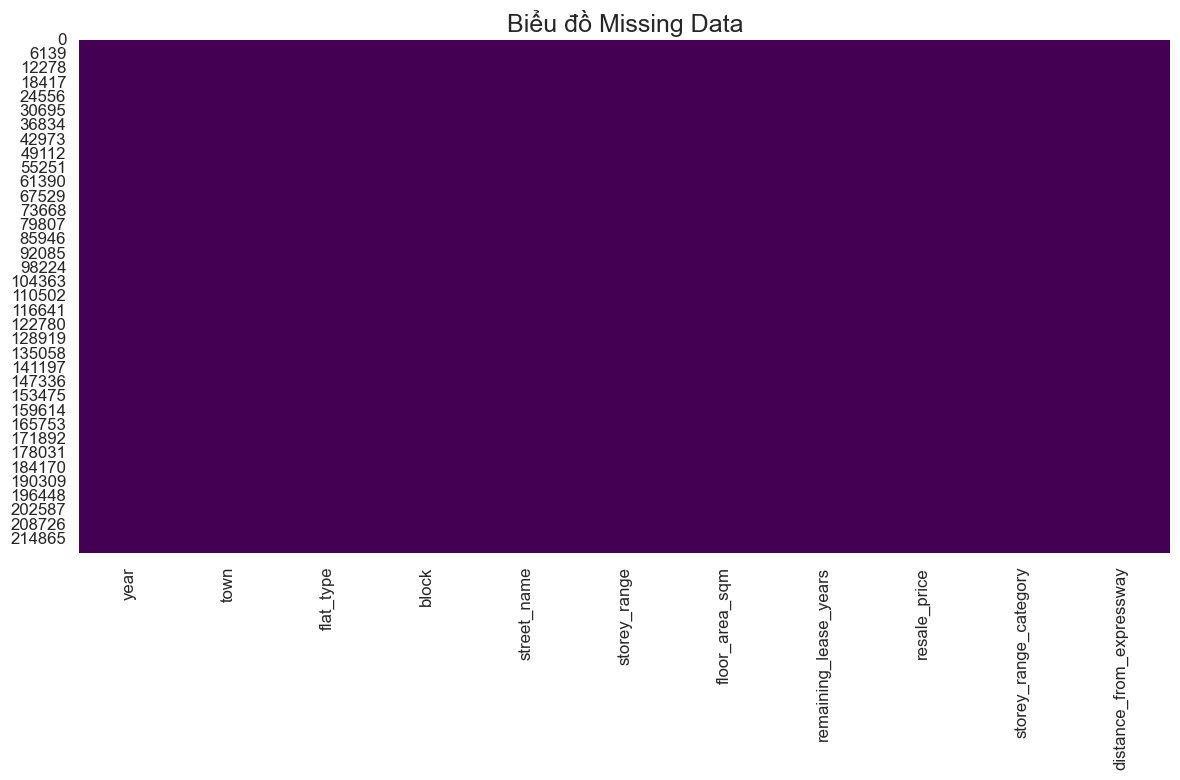

In [28]:
# 2. Kiểm tra missing values
print("\n=== Kiểm tra giá trị thiếu ===")
missing_values = data.isnull().sum()
print(missing_values)

plt.figure(figsize=(12, 8))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Biểu đồ Missing Data', fontsize=18)
plt.tight_layout()
plt.show()

### Phân tích phân bố resale_price

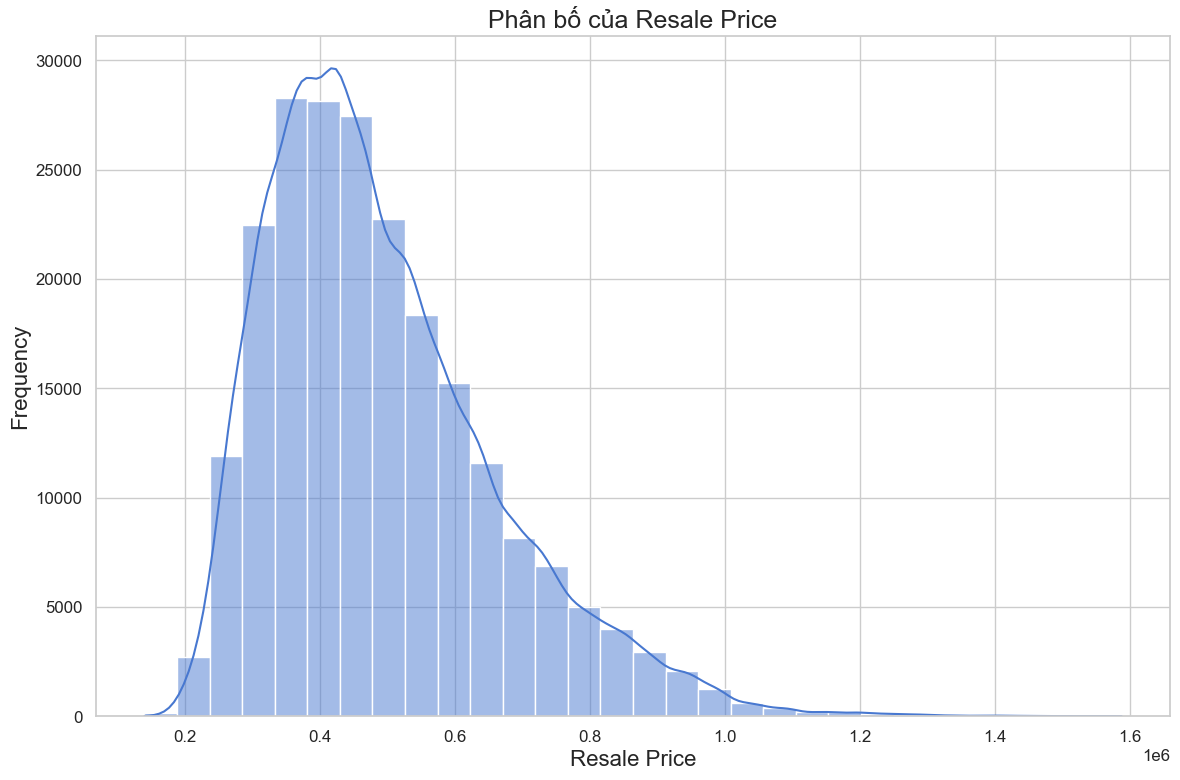

In [29]:
# 3. Phân tích phân bố resale_price
plt.figure(figsize=(12, 8))
sns.histplot(data['resale_price'], kde=True, bins=30)
plt.title("Phân bố của Resale Price", fontsize=18)
plt.xlabel("Resale Price", fontsize=16)
plt.ylabel("Frequency", fontsize=16)
plt.tight_layout()
plt.show()

> **💡 Nhận xét chuyên gia:** Giá bán (`resale_price`) bị lệch phải (right-skewed). Đa số nhà rơi vào tầm giá 300k - 500k. Những căn > 1 triệu đô khá hiếm.
> $\rightarrow$ **Định hướng Model:** Trong các mô hình Linear, phân phối lệch phải của target có thể làm giảm hiệu suất. Có thể cân nhắc dùng hàm Log-transform cho `resale_price` trước khi đưa vào mô hình nếu dùng Linear Regression. Tuy nhiên với các mô hình dạng Cây (Tree-based) thì sự lệch này ít ảnh hưởng hơn.

### Ma trận tương quan và pairplot

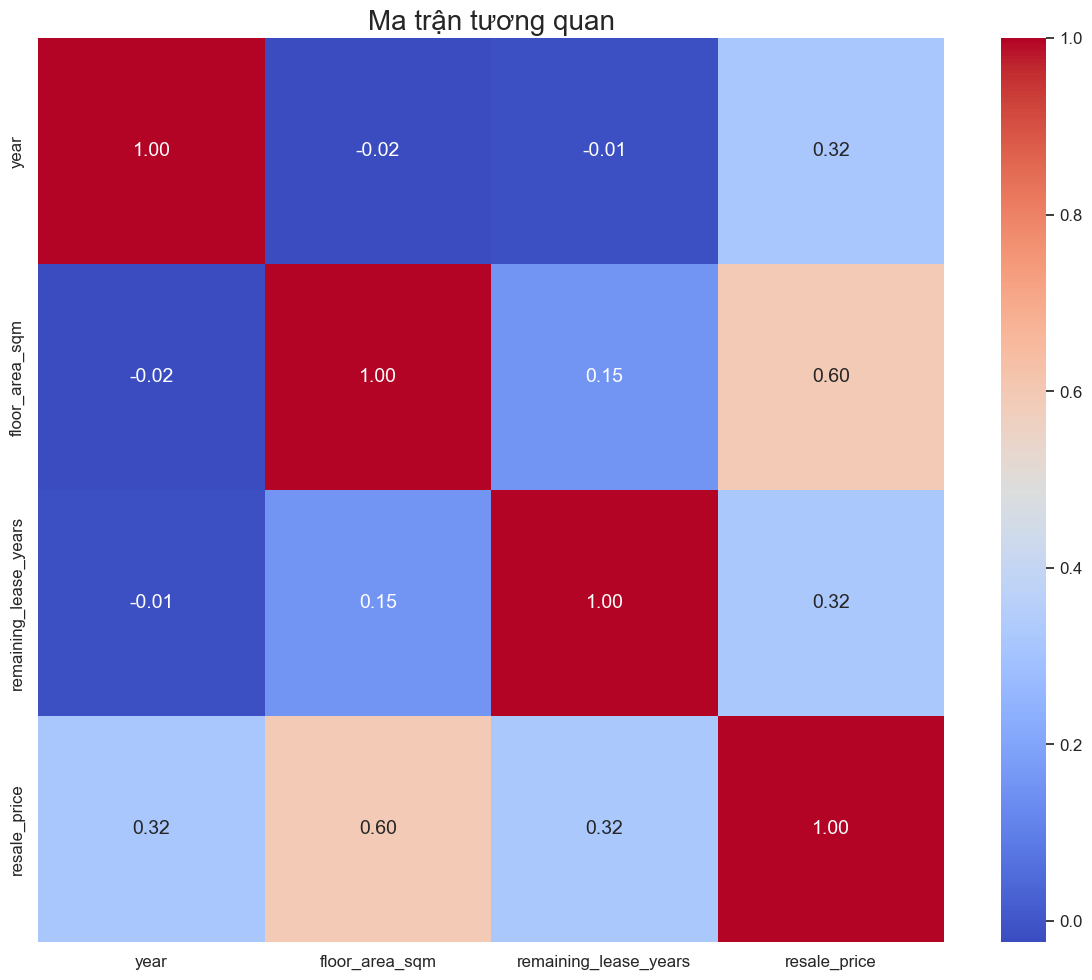

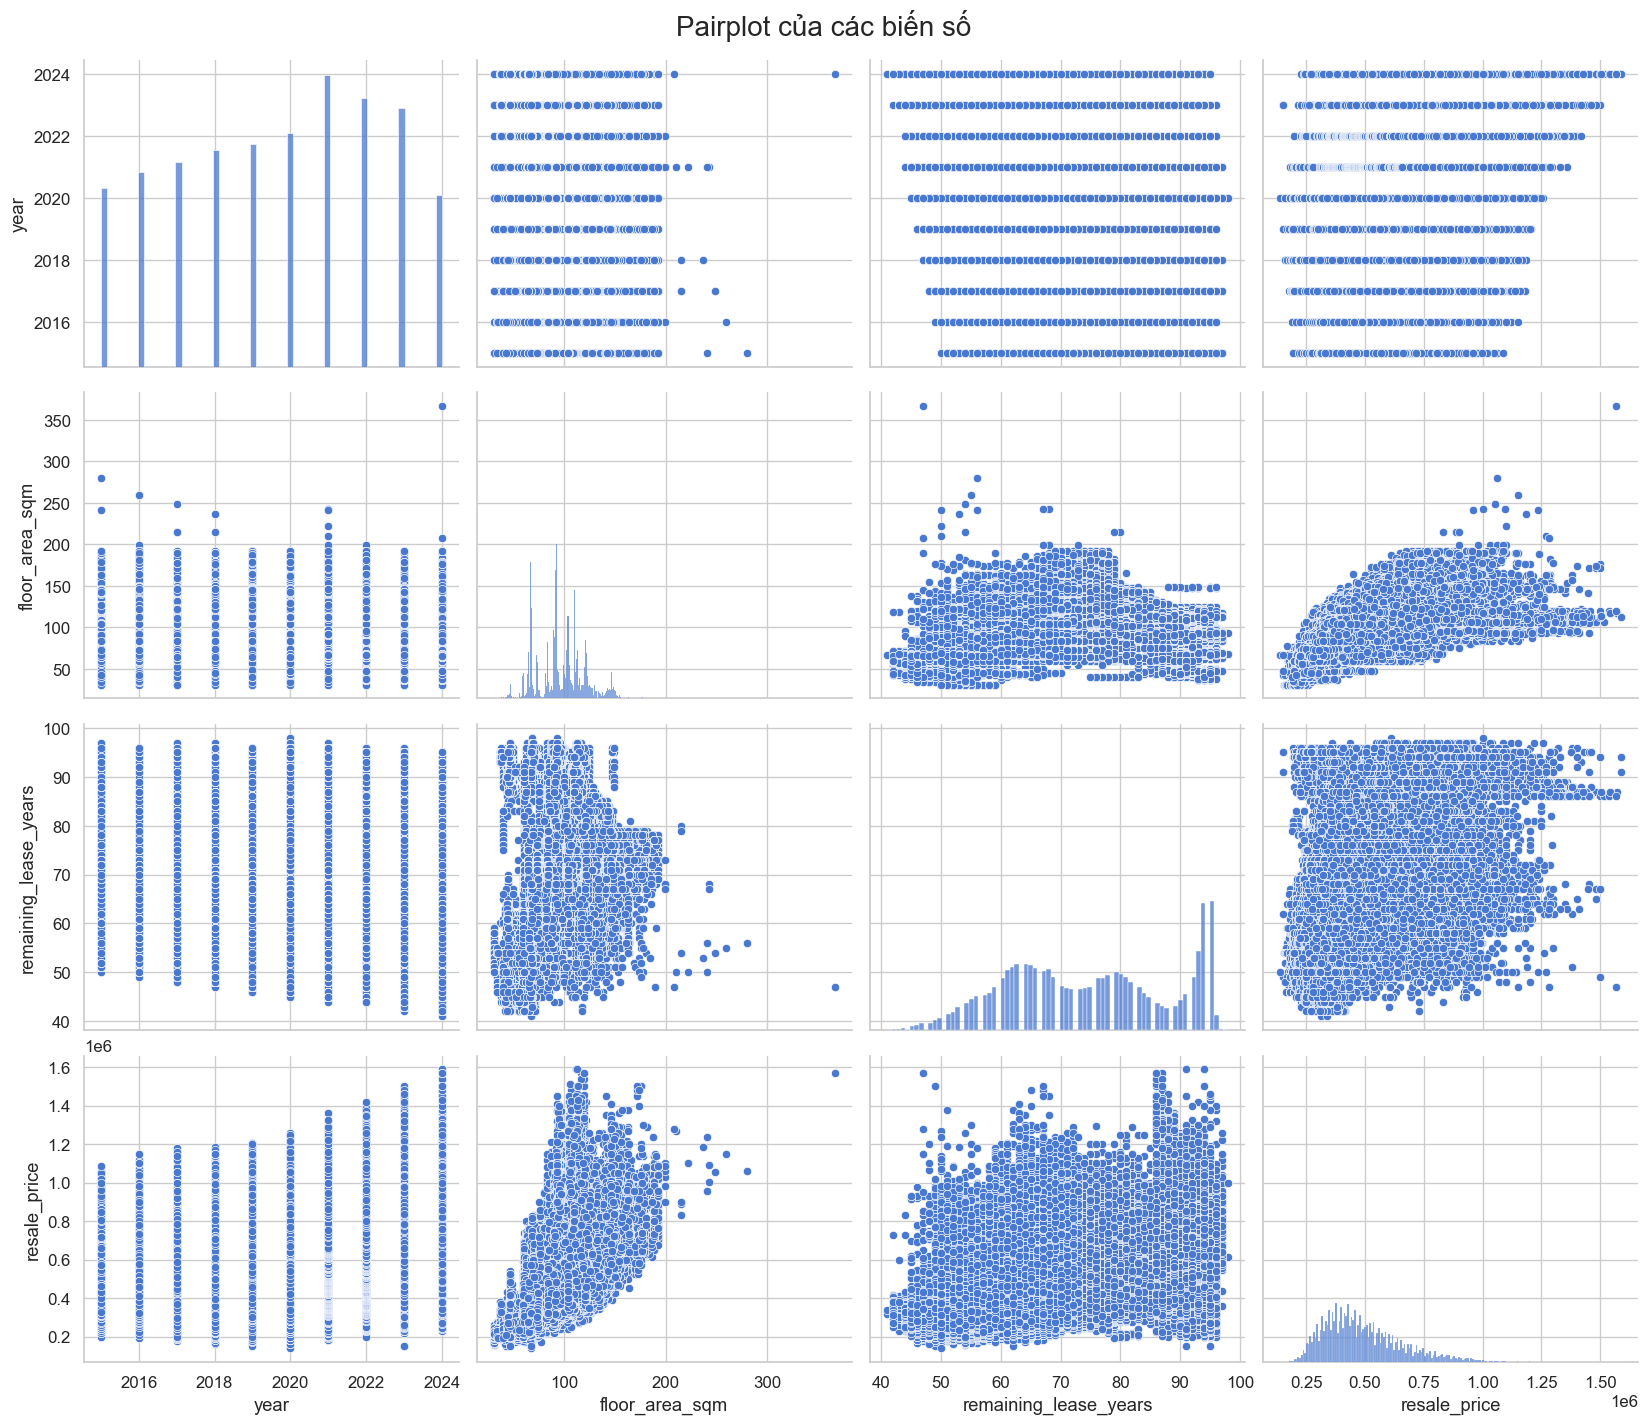

In [30]:
# 4. Ma trận tương quan và pairplot
numerical_features = ['year', 'floor_area_sqm', 'remaining_lease_years', 'resale_price']
corr_matrix = data[numerical_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", annot_kws={"size": 14})
plt.title("Ma trận tương quan", fontsize=20)
plt.tight_layout()
plt.show()

sns.pairplot(data[numerical_features], height=3.5, aspect=1.2)
plt.suptitle("Pairplot của các biến số", y=1.02, fontsize=20)
plt.show()

### Phân tích biến phân loại

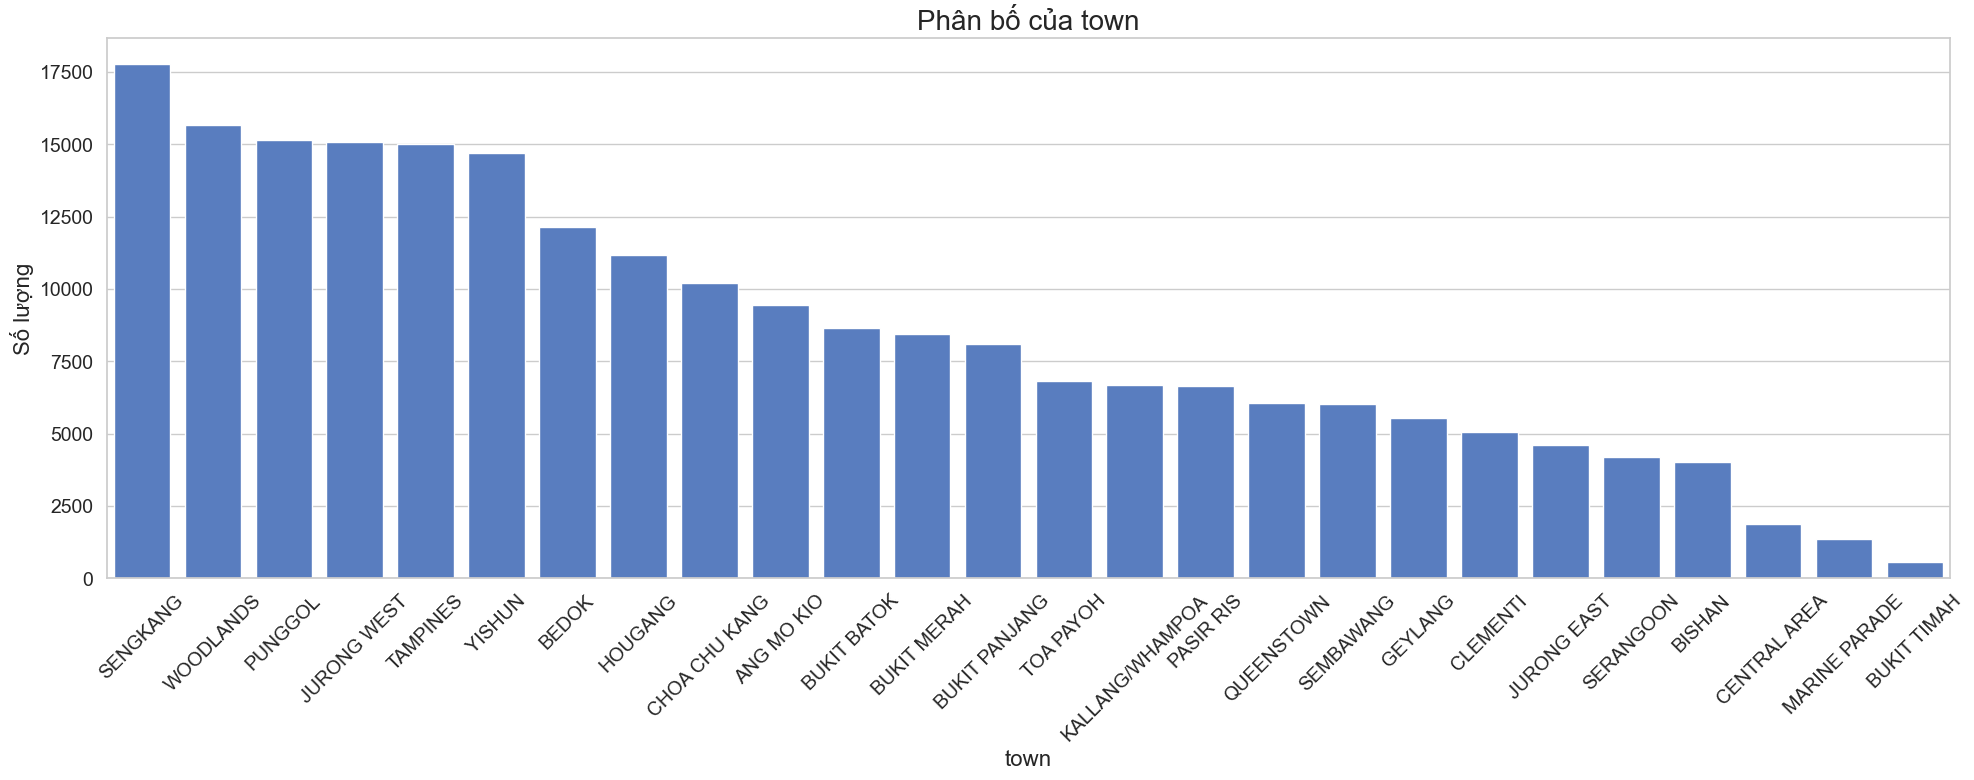

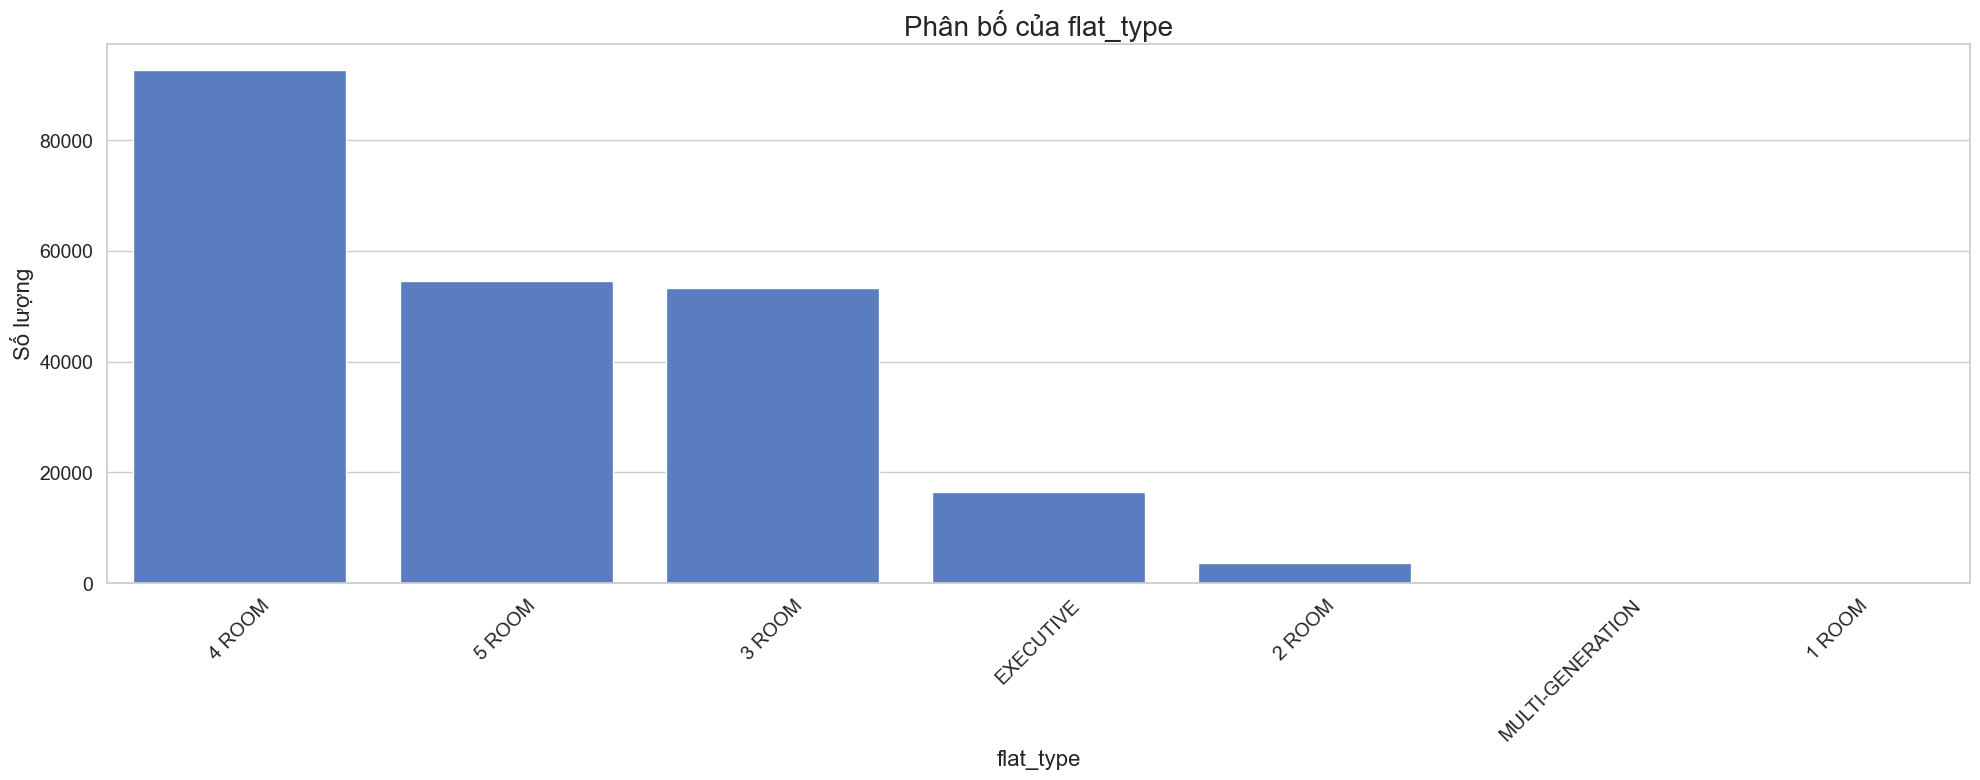

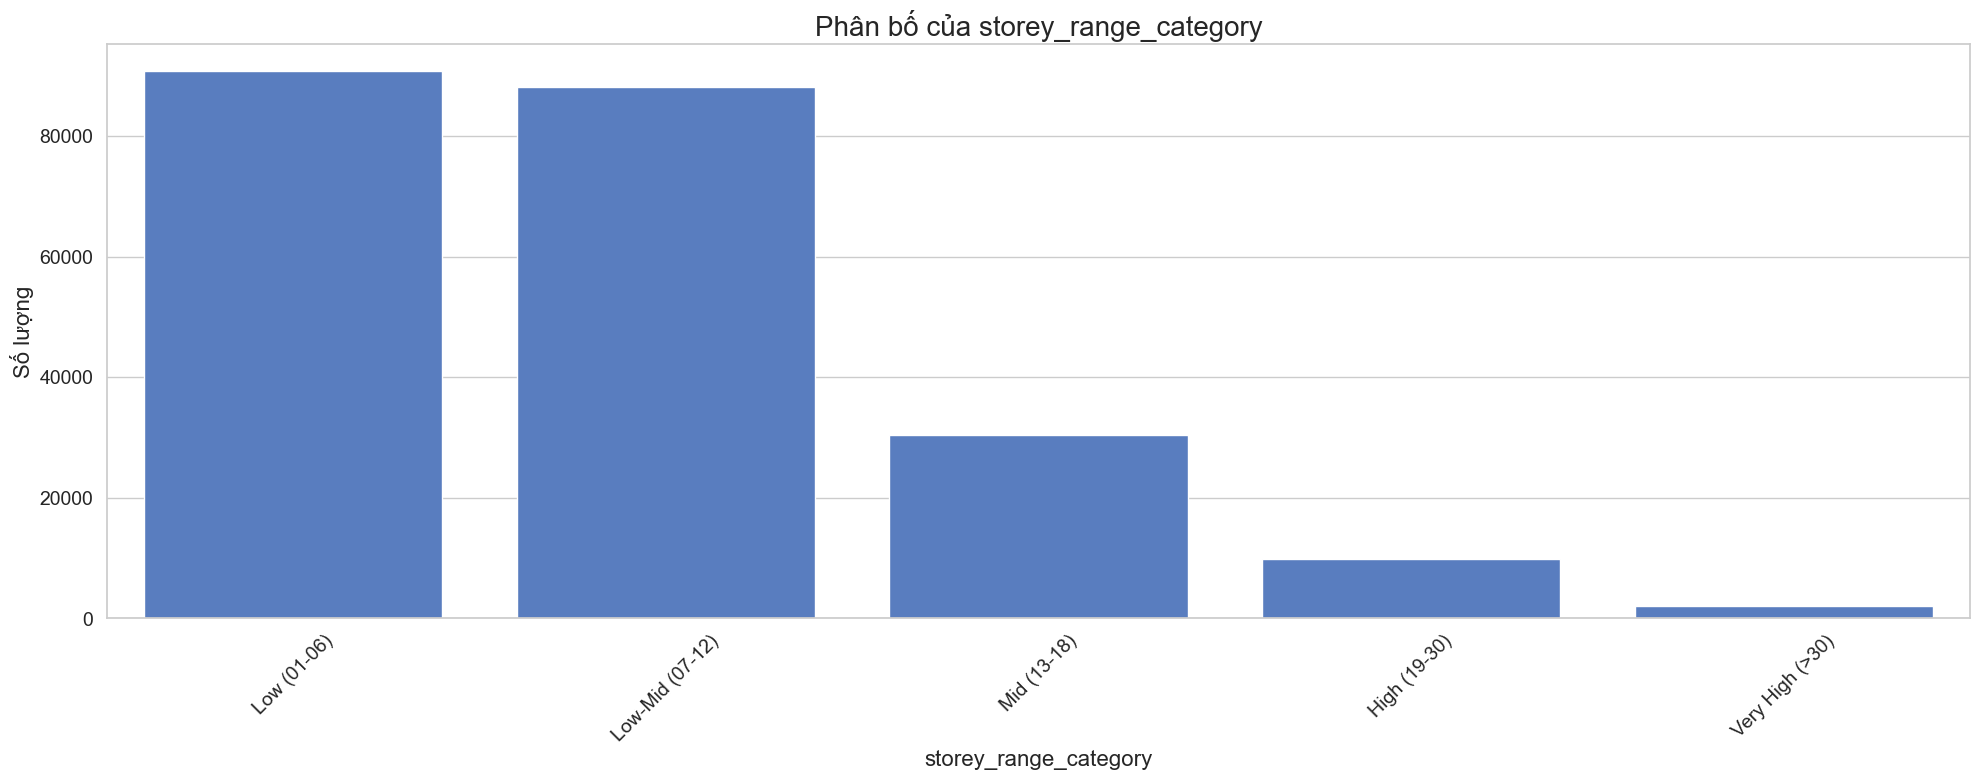

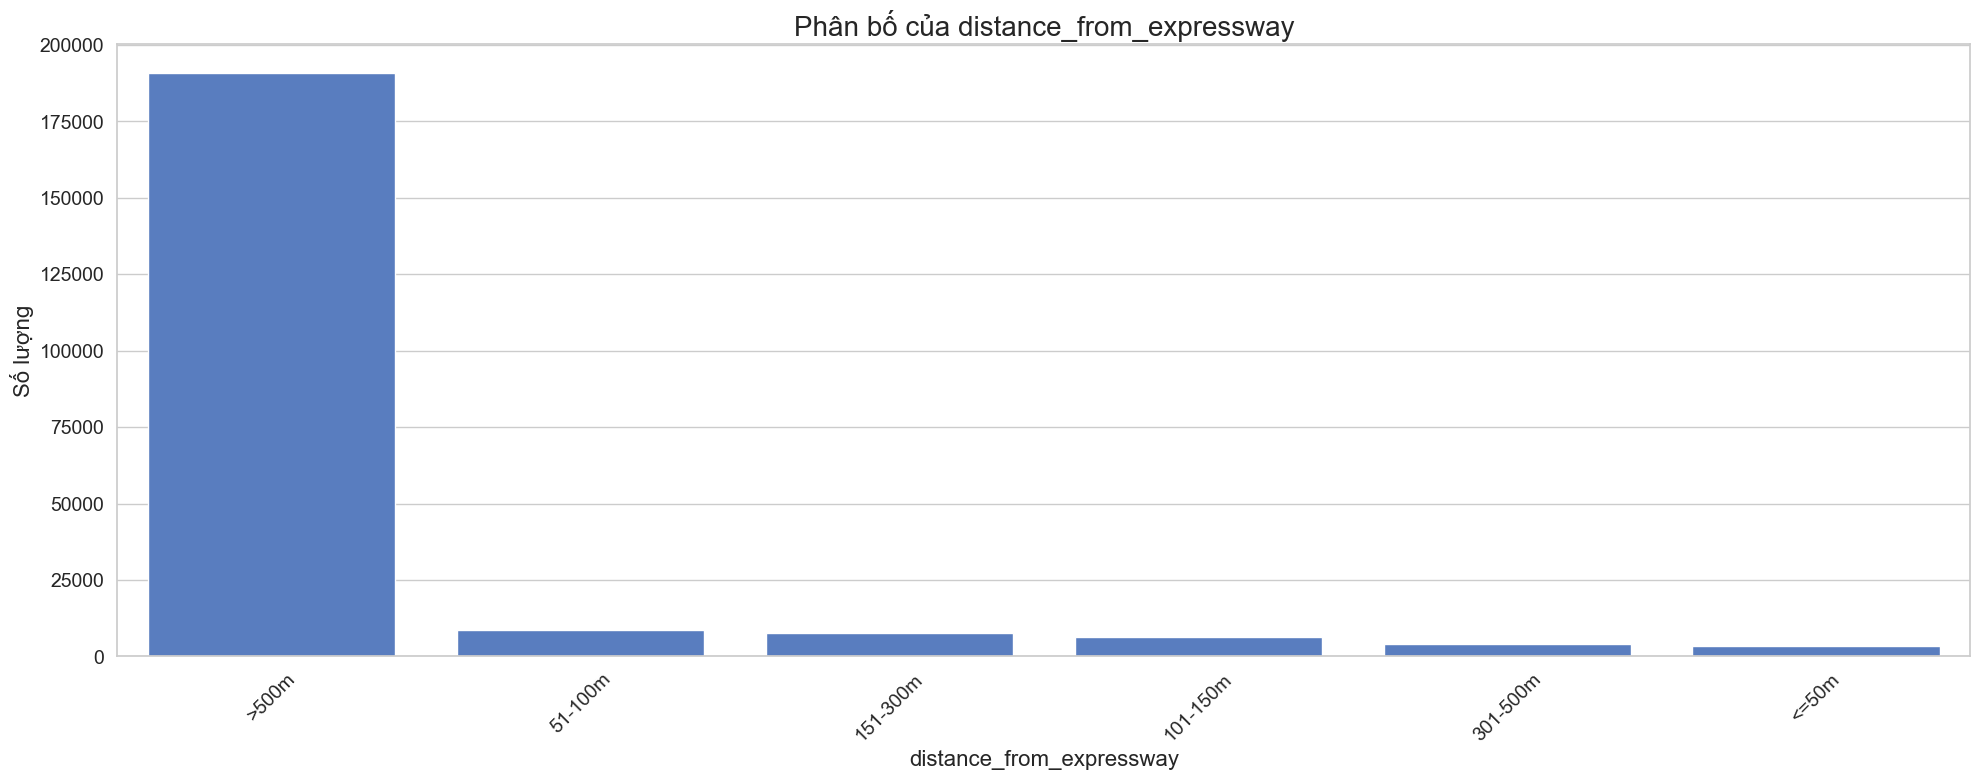

In [31]:
# 5. Phân tích biến phân loại
categorical_features = ['town', 'flat_type', 'storey_range_category', 'distance_from_expressway']

for cat in categorical_features:
    plt.figure(figsize=(20, 8))
    order = data[cat].value_counts().index
    sns.countplot(x=cat, data=data, order=order)
    plt.title(f"Phân bố của {cat}", fontsize=20)
    plt.xlabel(cat, fontsize=16)
    plt.ylabel("Số lượng", fontsize=16)
    plt.xticks(rotation=45, fontsize=14)
    plt.yticks(fontsize=14)
    plt.tight_layout()
    plt.show()

### Phát hiện ngoại lai bằng boxplot

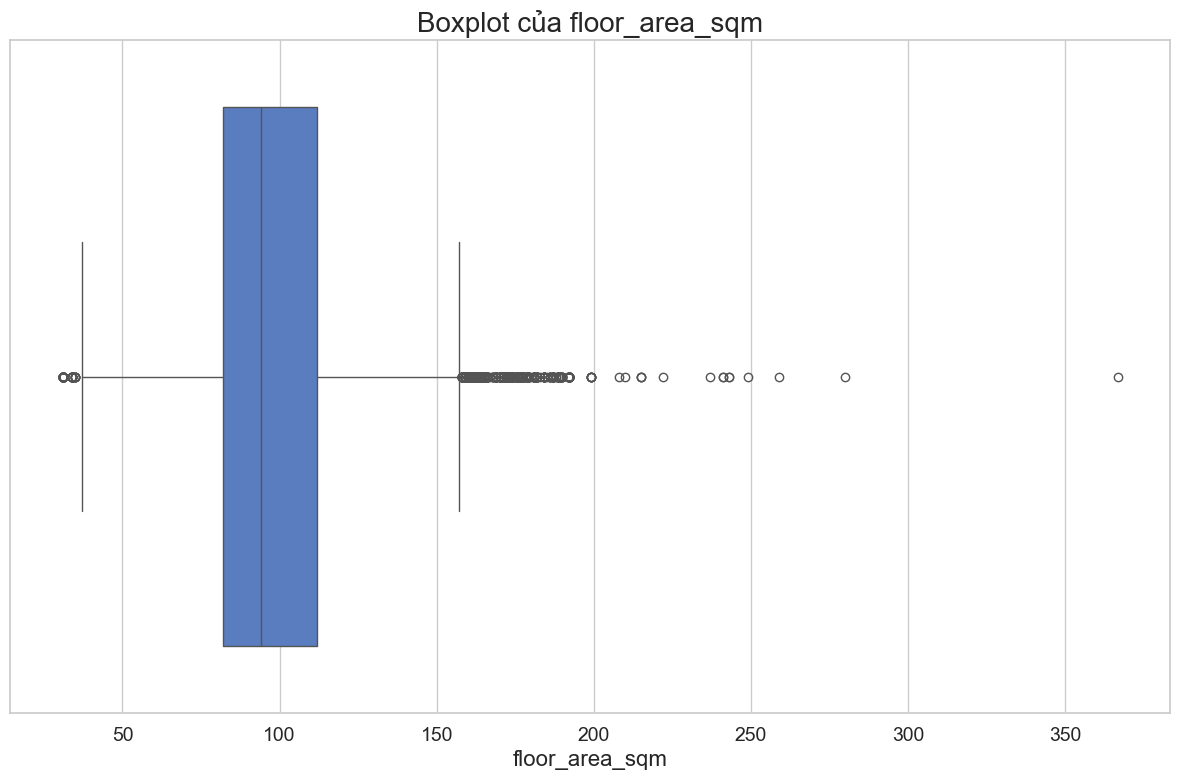

=== Ngoại lai của floor_area_sqm ===
194        34.0
195        34.0
699       161.0
701       165.0
1021      161.0
          ...  
220889    177.0
220890    177.0
220892    189.0
220968    181.0
220970    164.0
Name: floor_area_sqm, Length: 1268, dtype: float64


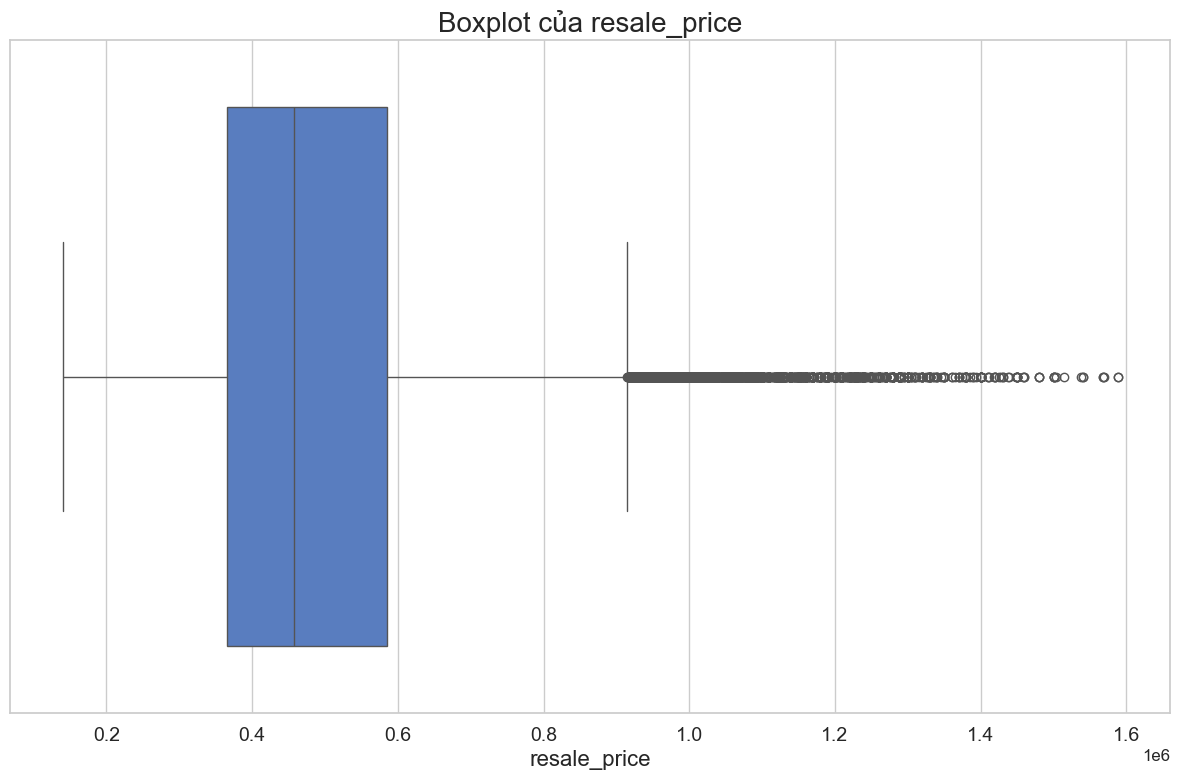

=== Ngoại lai của resale_price ===
307       1108000.0
659       1005000.0
1318      1180000.0
1385       955000.0
1386       980000.0
            ...    
219809     928000.0
219979     980000.0
219989     928888.0
219993     938888.0
220318    1150000.0
Name: resale_price, Length: 4902, dtype: float64


In [32]:
# 6. Phát hiện ngoại lai bằng boxplot
def detect_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series[(series < lower) | (series > upper)]

for col in ['floor_area_sqm', 'resale_price']:
    plt.figure(figsize=(12, 8))
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot của {col}", fontsize=20)
    plt.xlabel(col, fontsize=16)
    plt.xticks(fontsize=14)
    plt.tight_layout()
    plt.show()
    outliers = detect_outliers(data[col])
    print(f"=== Ngoại lai của {col} ===")
    print(outliers)

> **💡 Nhận xét chuyên gia:** Đã phát hiện ra một số lượng đáng kể các điểm ngoại lai cho giá nhà (giá rất cao). Tuy nhiên, trong lĩnh vực bất động sản, đây thường không phải là dữ liệu rác (garbage/errors) mà phản ánh đúng thực tế của những căn hộ cao cấp hoặc ở các khu vực đắc địa.
> $\rightarrow$ **Định hướng Model:** Quyết định **KHÔNG XÓA** các ngoại lai này để mô hình có khả năng dự đoán được các trường hợp nhà giá cao. Do đó, nên ưu tiên các mô hình mạnh mẽ với ngoại lai như Random Forest hoặc Gradient Boosting hơn là Linear Regression.

### Mối quan hệ resale_price vs floor_area_sqm

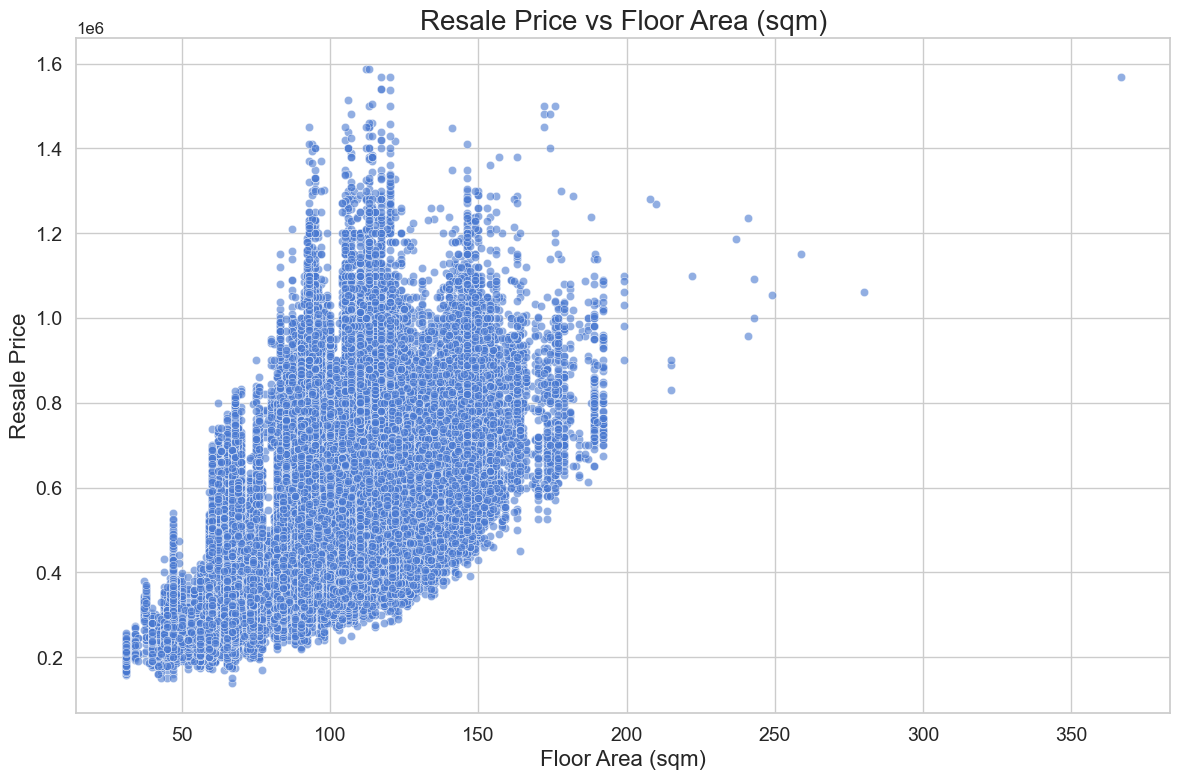

In [33]:
# 7. Mối quan hệ resale_price vs floor_area_sqm
plt.figure(figsize=(12, 8))
sns.scatterplot(x='floor_area_sqm', y='resale_price', data=data, alpha=0.6)
plt.title("Resale Price vs Floor Area (sqm)", fontsize=20)
plt.xlabel("Floor Area (sqm)", fontsize=16)
plt.ylabel("Resale Price", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

### Boxplot resale_price theo phân loại

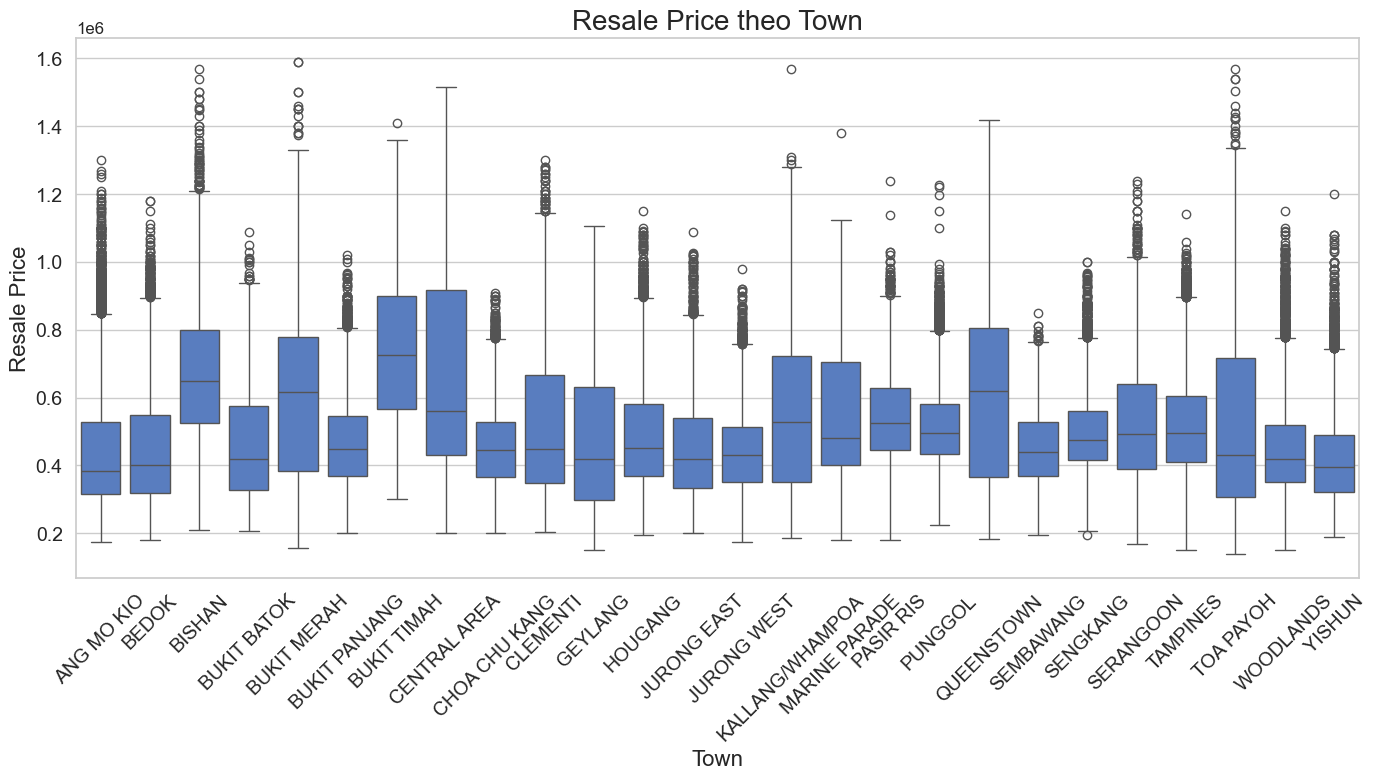

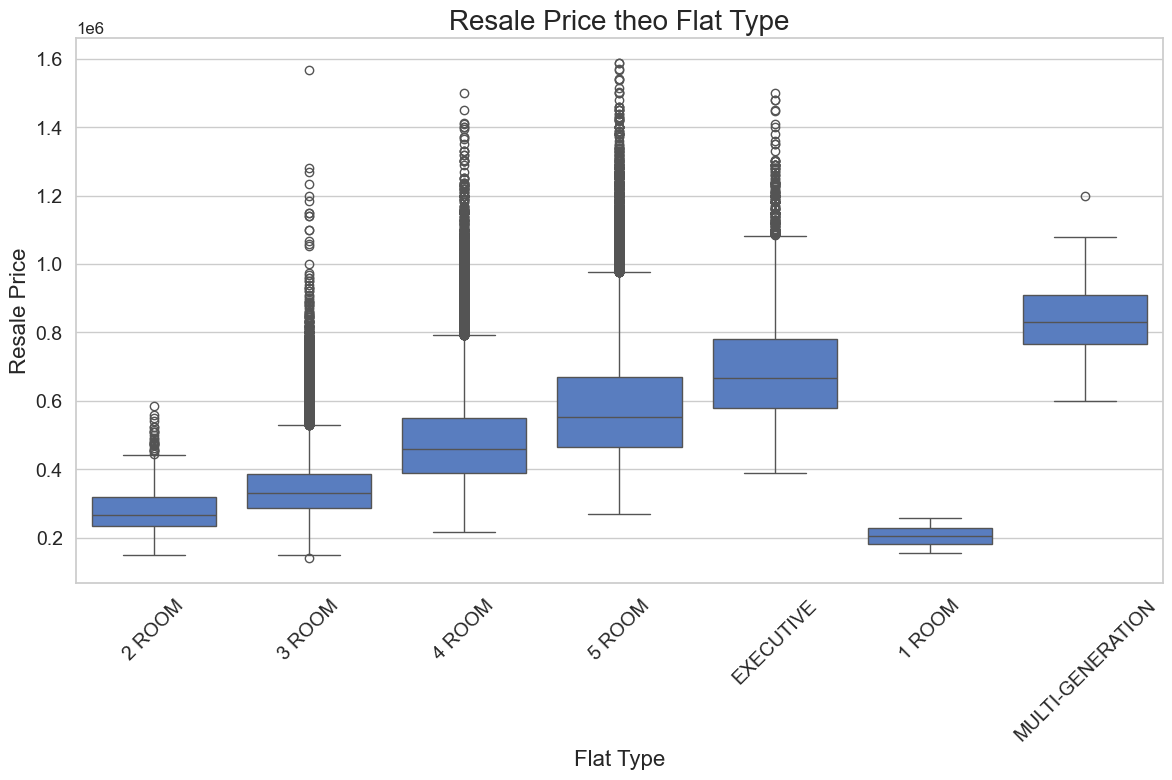

In [34]:
# 8. Boxplot resale_price theo phân loại
plt.figure(figsize=(14, 8))
sns.boxplot(x='town', y='resale_price', data=data)
plt.title("Resale Price theo Town", fontsize=20)
plt.xlabel("Town", fontsize=16)
plt.ylabel("Resale Price", fontsize=16)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
sns.boxplot(x='flat_type', y='resale_price', data=data)
plt.title("Resale Price theo Flat Type", fontsize=20)
plt.xlabel("Flat Type", fontsize=16)
plt.ylabel("Resale Price", fontsize=16)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

### Boxplot theo year

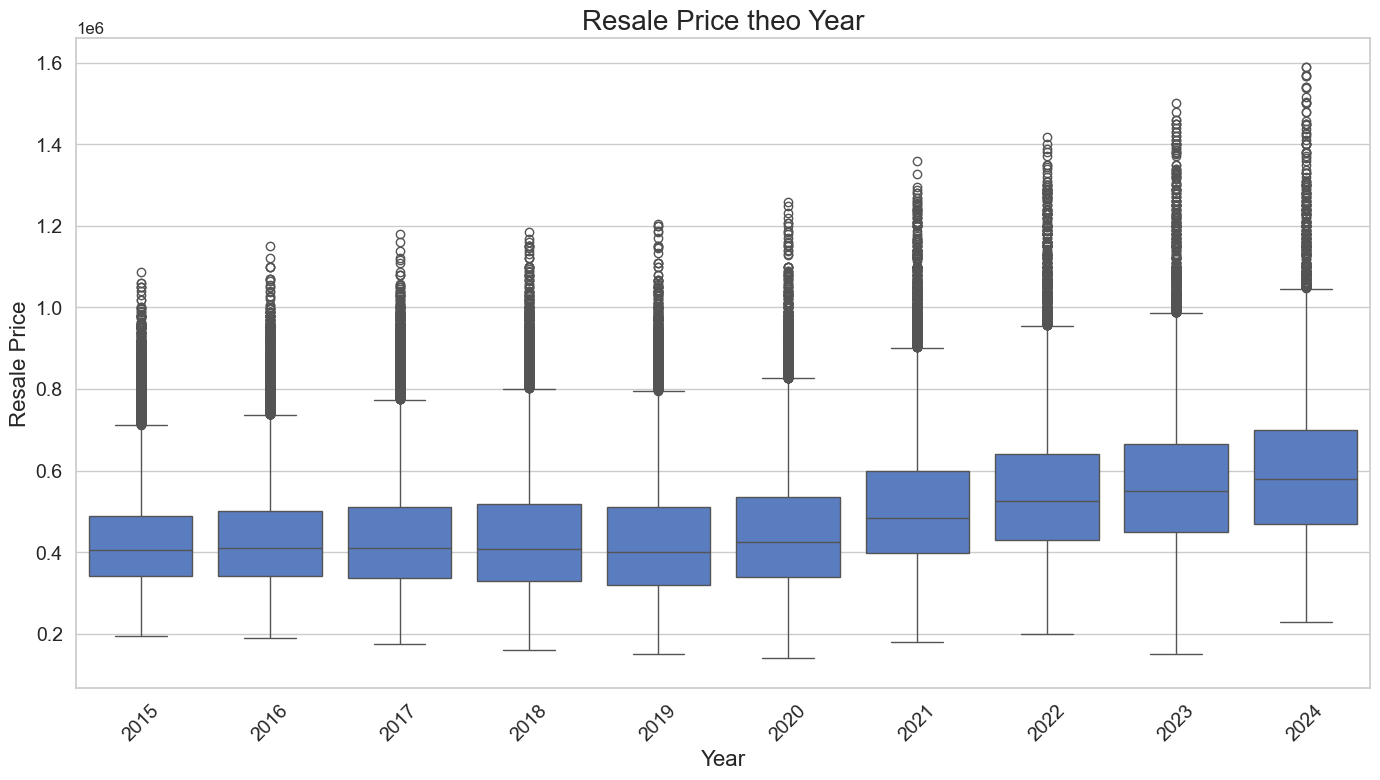

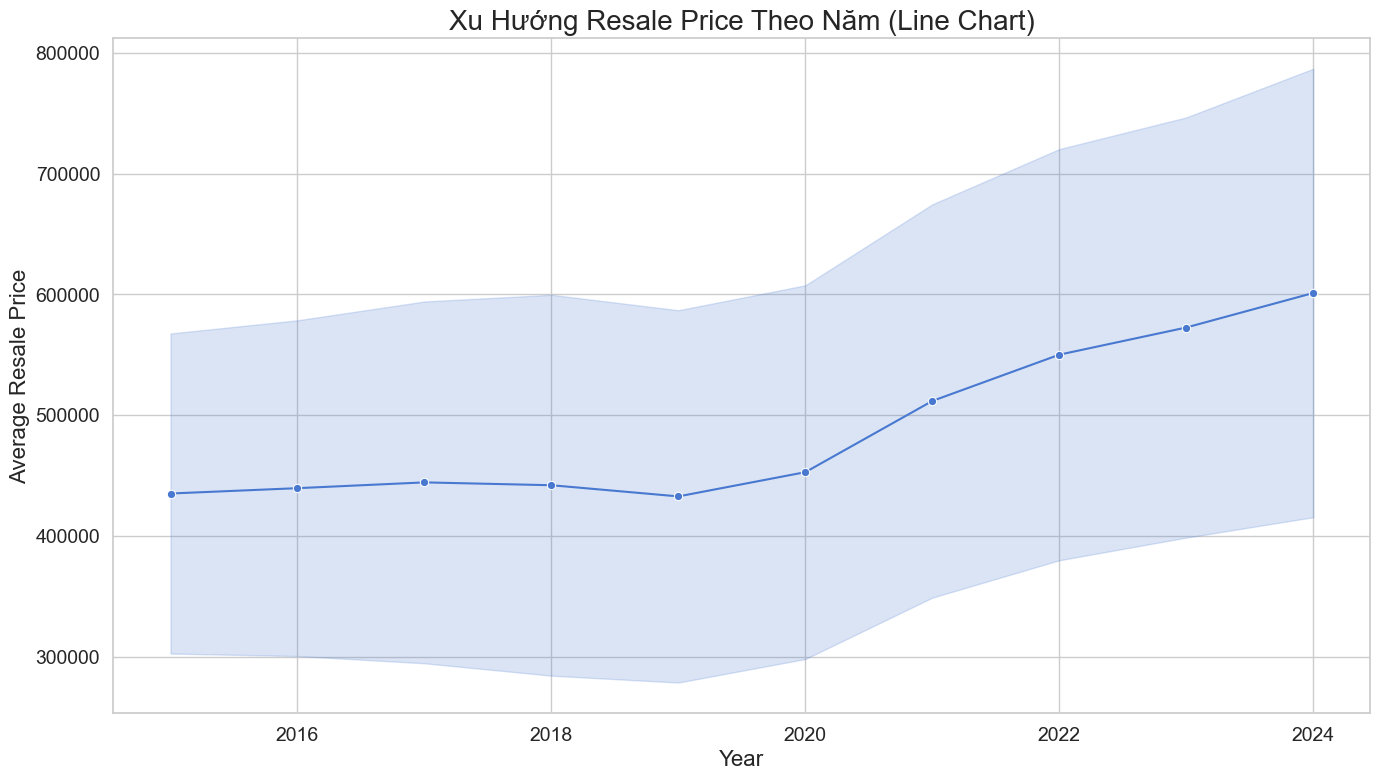

In [35]:
# 9. Boxplot theo year
plt.figure(figsize=(14, 8))
sns.boxplot(x='year', y='resale_price', data=data)
plt.title("Resale Price theo Year", fontsize=20)
plt.xlabel("Year", fontsize=16)
plt.ylabel("Resale Price", fontsize=16)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()


# Line chart để xem xu hướng theo năm
plt.figure(figsize=(14, 8))
sns.lineplot(x='year', y='resale_price', data=data, estimator='mean', errorbar='sd', marker='o')
plt.title("Xu Hướng Resale Price Theo Năm (Line Chart)", fontsize=20)
plt.xlabel("Year", fontsize=16)
plt.ylabel("Average Resale Price", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

> **💡 Nhận xét chuyên gia:** Biểu đồ đường giúp thấy rõ "Trend" (xu hướng) giá nhà theo thời gian. Có thể thấy sự biến động của trung bình giá bán qua các năm. Việc phân tích Time-Series/Trend này rất quan trọng để mô hình nắm bắt được yếu tố vĩ mô như lạm phát hoặc sự thay đổi cung cầu của thị trường bất động sản.

### Thử nghiệm Feature Engineering (Tạo Đặc Trưng Mới)

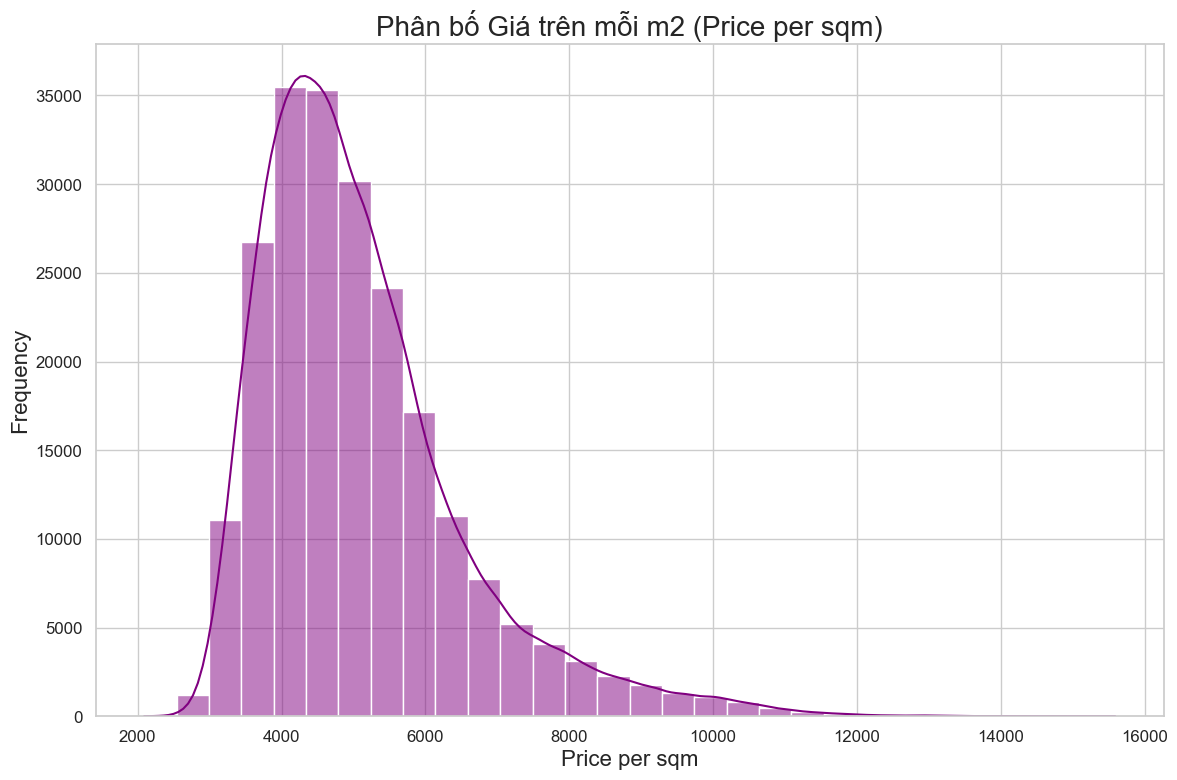

In [36]:
# 9.5 Thử nghiệm Feature Engineering
# Chuyên gia thường tạo ra tính năng mới để xem tương quan.
# Ví dụ: Giá trên mỗi m2
data_temp = data.copy()
data_temp['price_per_sqm'] = data_temp['resale_price'] / data_temp['floor_area_sqm']

plt.figure(figsize=(12, 8))
sns.histplot(data_temp['price_per_sqm'], kde=True, bins=30, color='purple')
plt.title("Phân bố Giá trên mỗi m2 (Price per sqm)", fontsize=20)
plt.xlabel("Price per sqm", fontsize=16)
plt.ylabel("Frequency", fontsize=16)
plt.tight_layout()
plt.show()

> **💡 Nhận xét chuyên gia:** Khám phá đặc trưng (Feature Engineering) ngay trong lúc EDA là một thói quen tốt. Biến mới `price_per_sqm` có thể mang tín hiệu (signal) tốt về độ đắt đỏ của từng khu vực độc lập với diện tích.

### Resale Price theo khoảng cách từ Expressway

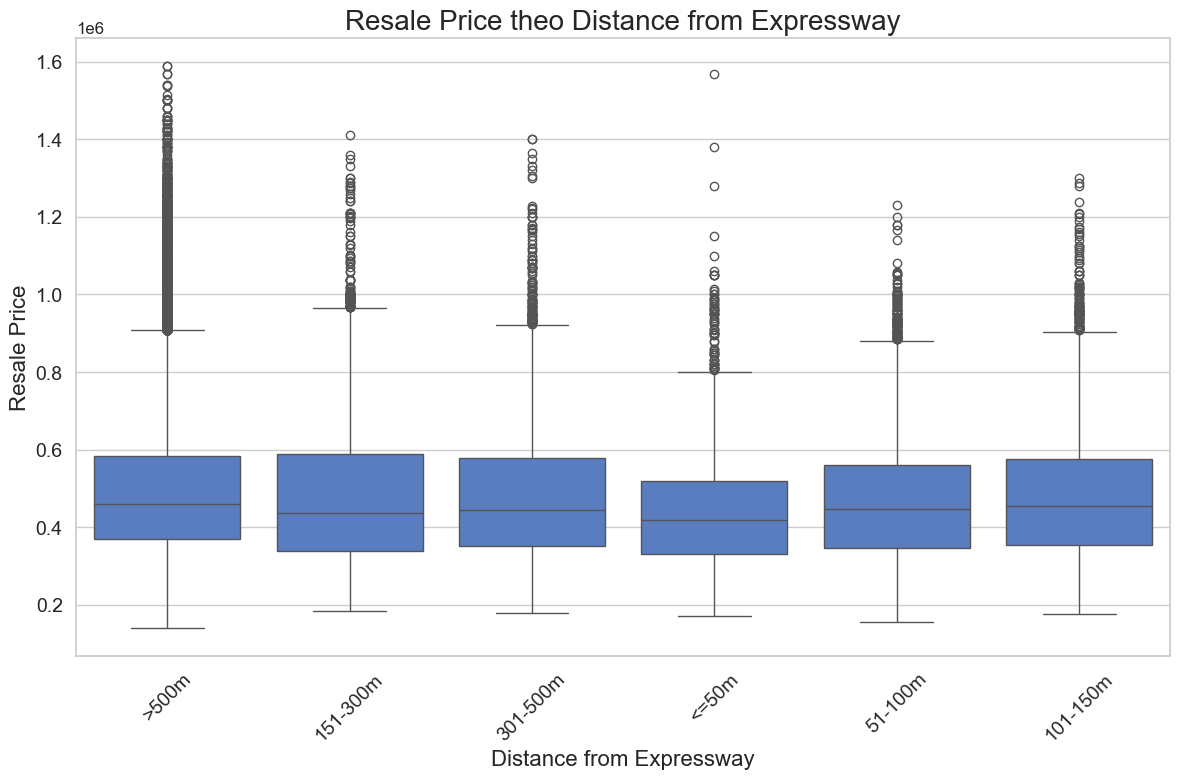

In [37]:
# 11. Resale Price theo khoảng cách từ Expressway
plt.figure(figsize=(12, 8))
sns.boxplot(x='distance_from_expressway', y='resale_price', data=data)
plt.title("Resale Price theo Distance from Expressway", fontsize=20)
plt.xlabel("Distance from Expressway", fontsize=16)
plt.ylabel("Resale Price", fontsize=16)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

### Tổng hợp kết quả EDA

In [38]:
# 12. Tổng hợp kết quả EDA
eda_results = {
    "Thông tin Dataset": "Đã hiển thị bằng data.info()",
    "Thống kê mô tả": "Đã hiển thị bằng data.describe()",
    "Missing Values": missing_values.to_dict(),
    "Ma trận tương quan": corr_matrix.to_dict(),
    "Các biểu đồ đã hiển thị": "Heatmap missing, histogram resale_price, boxplots, scatter plot, pairplot, countplots cho các biến phân loại..."
}

print("\n=== Kết quả EDA tổng hợp ===")
for name, info in eda_results.items():
    print(f"{name}: {info}")


=== Kết quả EDA tổng hợp ===
Thông tin Dataset: Đã hiển thị bằng data.info()
Thống kê mô tả: Đã hiển thị bằng data.describe()
Missing Values: {'year': 0, 'town': 0, 'flat_type': 0, 'block': 0, 'street_name': 0, 'storey_range': 0, 'floor_area_sqm': 0, 'remaining_lease_years': 0, 'resale_price': 0, 'storey_range_category': 0, 'distance_from_expressway': 0}
Ma trận tương quan: {'year': {'year': 1.0, 'floor_area_sqm': -0.02340379089357961, 'remaining_lease_years': -0.014430445902151104, 'resale_price': 0.31557252550309833}, 'floor_area_sqm': {'year': -0.02340379089357961, 'floor_area_sqm': 1.0, 'remaining_lease_years': 0.15332445604217268, 'resale_price': 0.5952850174943499}, 'remaining_lease_years': {'year': -0.014430445902151104, 'floor_area_sqm': 0.15332445604217268, 'remaining_lease_years': 1.0, 'resale_price': 0.3206110116137477}, 'resale_price': {'year': 0.31557252550309833, 'floor_area_sqm': 0.5952850174943499, 'remaining_lease_years': 0.3206110116137477, 'resale_price': 1.0}}
Các 

# Tiền Xử Lý Dữ Liệu

## Hàm Tiền Xử Lý 'distance_from_expressway'

In [39]:
def preprocess_distance(df):
    """
    Chuyển đổi cột 'distance_from_expressway' từ dạng chuỗi sang số.
    Xử lý các định dạng như '101-150m', '<=50m', '>500m', và '300m'.
    """
    def convert_distance(value):
        if isinstance(value, str):
            value = value.replace('m', '').strip()
            try:
                if '-' in value:
                    # Xử lý khoảng cách, ví dụ: '101-150m'
                    parts = value.split('-')
                    low = float(parts[0])
                    high = float(parts[1])
                    return (low + high) / 2
                elif value.startswith('<='):
                    # Xử lý '<=50m'
                    num = float(value.replace('<=', '').strip())
                    return num
                elif value.startswith('>'):
                    # Xử lý '>500m'
                    num = float(value.replace('>', '').strip())
                    return num
                else:
                    # Xử lý giá trị đơn lẻ, ví dụ: '300m'
                    return float(value)
            except (ValueError, TypeError):
                return np.nan  # Trả về NaN nếu không thể chuyển đổi
        elif np.issubdtype(type(value), np.number):
            return value
        else:
            return np.nan  # Trả về NaN cho các loại dữ liệu khác

    df['distance_from_expressway'] = df['distance_from_expressway'].apply(convert_distance)
    return df

## Hàm Tính Tỷ Lệ Dự Đoán Trong Khoảng Sai Số Nhất Định

In [40]:
def calculate_accuracy_percentage(y_true, y_pred, tolerance=0.10):
    """
    Tính tỷ lệ phần trăm dự đoán nằm trong ±tolerance (mặc định 10%) so với giá trị thực tế.
    """
    lower_bound = y_true * (1 - tolerance)
    upper_bound = y_true * (1 + tolerance)
    within_tolerance = ((y_pred >= lower_bound) & (y_pred <= upper_bound))
    accuracy_percentage = within_tolerance.mean() * 100
    return accuracy_percentage

## Xác Định Biến Mục Tiêu và Đặc Trưng

In [41]:
# Define target and features
target = 'resale_price'
features = ['year', 'town', 'flat_type', 'floor_area_sqm',
            'remaining_lease_years', 'distance_from_expressway',
            'storey_range_category', 'block', 'street_name']

## Loại Bỏ Các Hàng Có Giá Trị Thiếu Trong Biến Mục Tiêu

In [42]:
# Drop rows with missing target values
data = data.dropna(subset=[target])

## Phân Chia Dữ Liệu Thành Tập Huấn Luyện và Kiểm Tra

In [43]:
# Split the data (80% train, 20% test)
X = data[features].copy()
y = data[target]

# Preprocess 'distance_from_expressway' with updated function
X = preprocess_distance(X)

# Kiểm tra lại giá trị NaN sau khi chuyển đổi
print("\nGiá trị NaN trong 'distance_from_expressway' sau khi chuyển đổi:", X['distance_from_expressway'].isnull().sum())

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Reset index để dễ dàng căn chỉnh dữ liệu khi đánh giá
X_train, X_test = X_train.reset_index(drop=True), X_test.reset_index(drop=True)
y_train, y_test = y_train.reset_index(drop=True), y_test.reset_index(drop=True)


Giá trị NaN trong 'distance_from_expressway' sau khi chuyển đổi: 0


## Định Nghĩa Các Đặc Trưng Phân Loại và Số

In [44]:
# Define categorical and numerical features
numerical_features = ['year', 'floor_area_sqm', 'remaining_lease_years', 'distance_from_expressway']
categorical_features = ['town', 'flat_type', 'storey_range_category']
high_cardinality_features = ['block', 'street_name']

# So sánh các model

In [45]:
%matplotlib inline

### Chuẩn Bị Dữ Liệu Cho Baseline Model

In [46]:
# !pip install xgboost lightgbm

In [47]:
# === IMPORT THƯ VIỆN ===
import numpy as np
import pandas as pd
from sklearn.base import clone
import time
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder
from sklearn.pipeline import Pipeline

### Định Nghĩa Baseline Pipeline & Hàm Đánh Giá

In [48]:
# === ĐỊNH NGHĨA TIỀN XỬ LÝ NHANH ===
quick_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['town', 'flat_type', 'storey_range_category']),
        ('high_cat', TargetEncoder(), ['block', 'street_name'])
    ],
    remainder='passthrough'
)



# === ĐỊNH NGHĨA MÔ HÌNH ===
models = {
    "Linear Regression": Pipeline(steps=[('preprocessor', clone(quick_preprocessor)), ('model', LinearRegression())]), # Baseline
    "Random Forest": Pipeline(steps=[('preprocessor', clone(quick_preprocessor)), ('model', RandomForestRegressor(random_state=42, n_jobs=-1))]), # Bagging chuẩn
    "XGBoost": Pipeline(steps=[('preprocessor', clone(quick_preprocessor)), ('model', xgb.XGBRegressor(random_state=42, n_jobs=-1))]), # Boosting công nghiệp
    "LightGBM": Pipeline(steps=[('preprocessor', clone(quick_preprocessor)), ('model', lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1))]) # Boosting tốc độ cao
}



# === HÀM ĐÁNH GIÁ ===
def evaluate_model(model, X_train, y_train, X_test, y_test):
    start_time = time.time()
    model.fit(X_train, y_train)
    elapsed_time = time.time() - start_time

    y_pred = model.predict(X_test)
    return {
        "Training Time (s)": round(elapsed_time, 2),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE": mean_absolute_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred)
    }

### Huấn Luyện & Đánh Giá Baseline

In [49]:
# === CHẠY SO SÁNH ===
results = {name: evaluate_model(model, X_train, y_train, X_test, y_test) for name, model in models.items()}
results_df = pd.DataFrame(results).T.sort_values("RMSE")



# === IN KẾT QUẢ ===
print("\n=== So sánh nhanh các mô hình ===")
print(results_df)


=== So sánh nhanh các mô hình ===
                   Training Time (s)          RMSE           MAE        R2
Random Forest                 600.64  32836.838381  22998.766171  0.963018
XGBoost                         0.92  35136.952627  25606.217608  0.957656
LightGBM                        0.76  40495.107653  29392.219545  0.943757
Linear Regression               0.38  84975.014254  63420.223673  0.752346


c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### Trực Quan Hóa Kết Quả Baseline

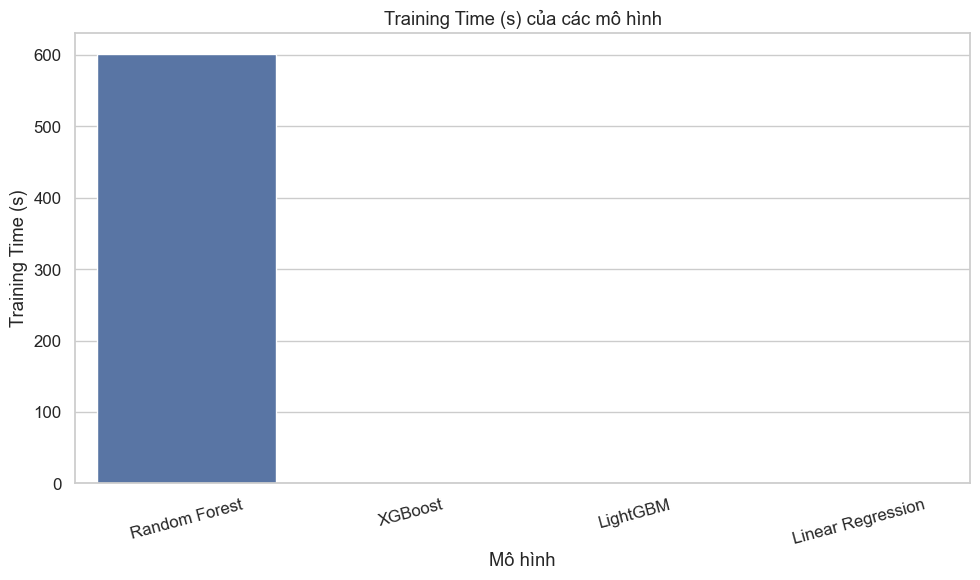

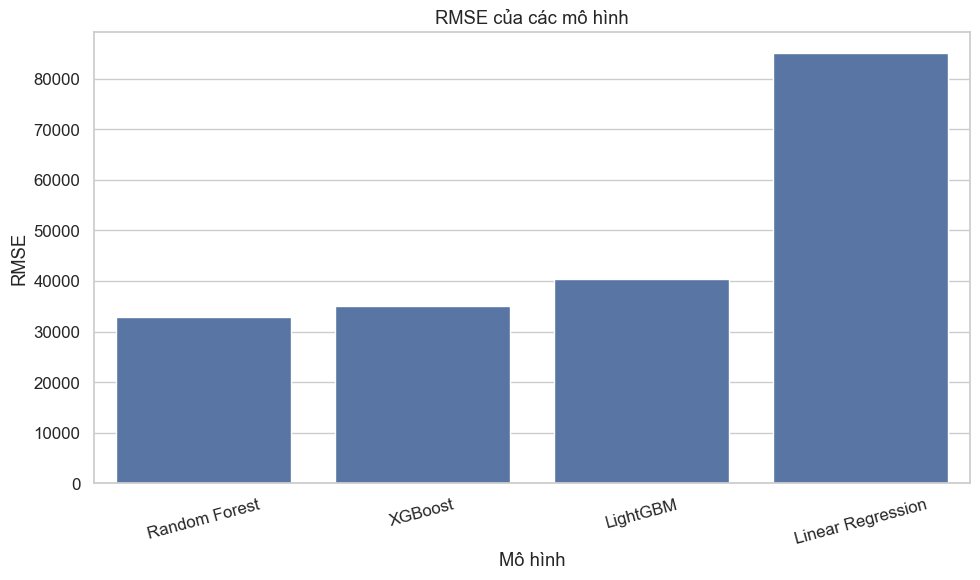

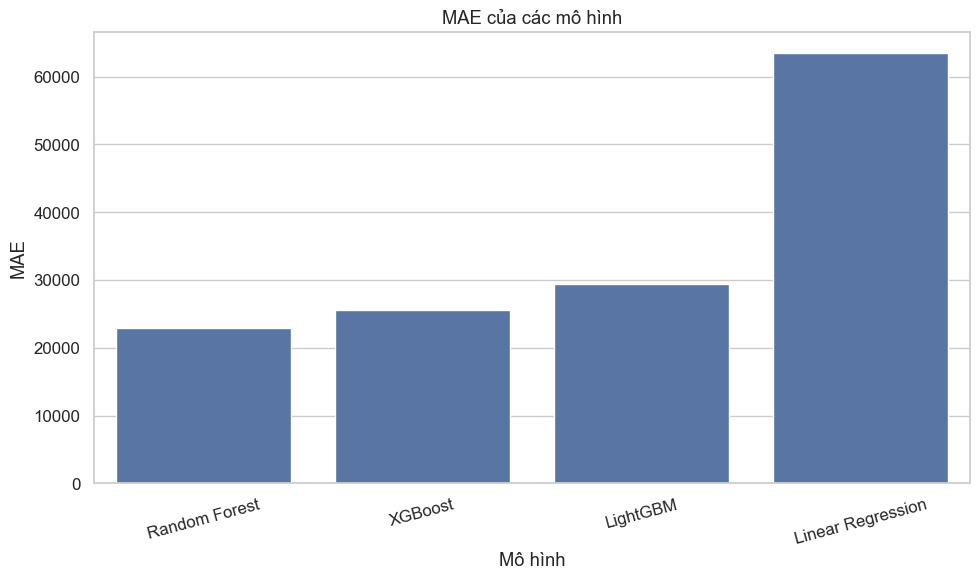

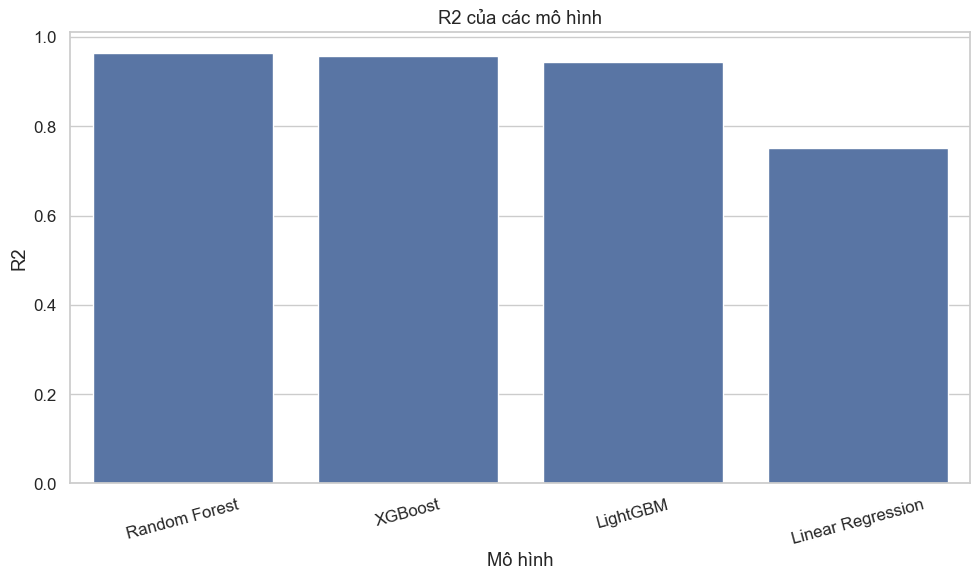

In [50]:
# === TRỰC QUAN HÓA ===
sns.set(style="whitegrid", font_scale=1.1)
metrics = ["Training Time (s)", "RMSE", "MAE", "R2"]

for metric in metrics:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=results_df.index, y=results_df[metric])
    plt.title(f"{metric} của các mô hình")
    plt.ylabel(metric)
    plt.xlabel("Mô hình")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

## Xây Dựng Các Pipeline Tiền Xử Lý

In [51]:
# Preprocessing cho dữ liệu số: Impute và Scale
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing cho dữ liệu phân loại ít giá trị: Impute và One-Hot Encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Preprocessing cho dữ liệu phân loại nhiều giá trị: Target Encoding
target_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target', TargetEncoder())
])

# Kết hợp các bước tiền xử lý
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features),
        ('high_cat', target_transformer, high_cardinality_features)
    ]
)

# Xây Dựng Model

## Xây Dựng Pipeline với Random Forest

In [52]:
# Step 3: Build ML Model
# Tạo pipeline với Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))
])

## Định Nghĩa Phân Phối Siêu Tham Số cho RandomizedSearchCV

In [53]:
# Định nghĩa phân phối siêu tham số cho RandomizedSearchCV
param_dist = {
    'regressor__n_estimators': randint(70, 90),         # Tập trung quanh giá trị 79
    'regressor__max_depth': [None, 10, 20, 30],             # Tuning độ sâu của cây
    'regressor__min_samples_split': randint(8, 11),     # Tập trung quanh giá trị 9
    'regressor__min_samples_leaf': randint(1, 3)        # Tập trung quanh giá trị 2
}

## Khởi Tạo và Huấn Luyện RandomizedSearchCV

In [54]:
# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist,
    n_iter=20,               # Số lượng tổ hợp thử nghiệm ngẫu nhiên
    cv=3,                    # Số fold trong cross-validation
    scoring='r2',
    n_jobs=-1,
    verbose=2,
    random_state=42,
    error_score='raise'     # Đặt để lỗi không bị bỏ qua
)

# Huấn luyện mô hình với Randomized Search
try:
    random_search.fit(X_train, y_train)
except Exception as e:
    print("Error during Randomized Search:", e)
    raise

# In ra siêu tham số tốt nhất
print("\nSiêu tham số tốt nhất:", random_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Siêu tham số tốt nhất: {'regressor__max_depth': 30, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 10, 'regressor__n_estimators': 72}


# Đánh Giá Mô Hình

## Dự Đoán và Tính Toán Các Chỉ Số Đánh Giá

In [55]:
# Step 4: Evaluation
# Dự đoán trên tập huấn luyện và kiểm tra
y_pred_train = random_search.predict(X_train)
y_pred_test = random_search.predict(X_test)

# Tính các chỉ số đánh giá
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

## In Kết Quả Đánh Giá

In [56]:
# In kết quả đánh giá
print("\nĐánh giá mô hình:")
print(f"Train Mean Squared Error: {mse_train:.2f}")
print(f"Test Mean Squared Error: {mse_test:.2f}")
print(f"Train Root Mean Squared Error: {rmse_train:.2f}")
print(f"Test Root Mean Squared Error: {rmse_test:.2f}")
print(f"Train Mean Absolute Error: {mae_train:.2f}")
print(f"Test Mean Absolute Error: {mae_test:.2f}")
print(f"Train R-squared: {r2_train:.4f}")
print(f"Test R-squared: {r2_test:.4f}")

# Kiểm tra overfitting
if r2_train - r2_test > 0.1:
    print("Mô hình có thể đang bị overfitting. Hãy xem xét điều chỉnh thêm các siêu tham số hoặc đơn giản hóa mô hình.")
else:
    print("Mô hình không có dấu hiệu bị overfitting.")


Đánh giá mô hình:
Train Mean Squared Error: 634863401.37
Test Mean Squared Error: 1110696013.39
Train Root Mean Squared Error: 25196.50
Test Root Mean Squared Error: 33327.11
Train Mean Absolute Error: 17968.03
Test Mean Absolute Error: 23177.07
Train R-squared: 0.9781
Test R-squared: 0.9619
Mô hình không có dấu hiệu bị overfitting.


## So Sánh Giá Trên Tập Kiểm Tra

In [57]:
# Output actual vs predicted prices for the test set
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_test
}).reset_index(drop=True)

print("\nMột số kết quả thực tế và dự đoán:")
print(results.head())


Một số kết quả thực tế và dự đoán:
     Actual      Predicted
0  805000.0  761304.049045
1  510000.0  484925.324380
2  472000.0  471781.848681
3  358000.0  343544.700274
4  480000.0  465758.120107


# Đánh Giá Bổ Sung

## Phân Tích Phần Trăm Dự Đoán Chính Xác

In [58]:
# Step 5: Additional Evaluation

## 1. Phân Tích Phần Trăm Dự Đoán Chính Xác
accuracy_10 = calculate_accuracy_percentage(y_test, y_pred_test, tolerance=0.10)
accuracy_5 = calculate_accuracy_percentage(y_test, y_pred_test, tolerance=0.05)

print(f"\nTỷ lệ dự đoán trong ±10%: {accuracy_10:.2f}%")
print(f"Tỷ lệ dự đoán trong ±5%: {accuracy_5:.2f}%")


Tỷ lệ dự đoán trong ±10%: 89.53%
Tỷ lệ dự đoán trong ±5%: 63.59%


## Phân Tích Residual (Sai Số Dự Đoán)

In [59]:
## 2. Phân Tích Residual (Sai Số Dự Đoán)
# Tính residual
residuals = y_test - y_pred_test

# Phân phối residual
plt.figure(figsize=(8,6))
sns.histplot(residuals, kde=True, bins=30, color='purple')
plt.title("Phân phối Residuals")
plt.xlabel("Residual")
plt.ylabel("Tần suất")
plt.savefig('residuals_distribution.png')
plt.close()

# Plot residuals vs predicted values
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred_test, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Giá Bán Lại Dự Đoán")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Values")
plt.savefig('residuals_vs_predicted.png')
plt.close()

## Hiển Thị Đường 45 Độ

In [60]:
## 3. Hiển Thị Đường 45 Độ
plt.figure(figsize=(8,6))
sns.scatterplot(x='Actual', y='Predicted', data=results, alpha=0.6)
plt.plot([results['Actual'].min(), results['Actual'].max()],
         [results['Actual'].min(), results['Actual'].max()],
         color='red', linestyle='--', label='y = x')
plt.xlabel("Giá Bán Lại Thực Tế")
plt.ylabel("Giá Bán Lại Dự Đoán")
plt.title("So Sánh Giá Bán Lại Thực Tế và Dự Đoán với Đường y = x")
plt.legend()
plt.savefig('actual_vs_predicted_with_line.png')
plt.close()

## Kiểm Tra Độ Chính Xác Theo Phân Nhóm (Theo Khu Vực)

In [61]:
## 4. Kiểm Tra Độ Chính Xác Theo Phân Nhóm
# Tính độ chính xác theo từng khu vực (town)


# Sao chép kết quả và thêm cột 'Town'
town_accuracy = results.copy()
town_accuracy['Town'] = X_test['town'].values

# Tính toán cột 'Within_10%'
town_accuracy['Within_10%'] = (town_accuracy['Predicted'] >= y_test * 0.90) & (town_accuracy['Predicted'] <= y_test * 1.10)

# Tính độ chính xác theo từng khu vực (Town)
accuracy_by_town = town_accuracy.groupby('Town')['Within_10%'].mean() * 100

print("\nĐộ chính xác trong ±10% theo từng khu vực:")
print(accuracy_by_town.sort_values(ascending=False))


Độ chính xác trong ±10% theo từng khu vực:
Town
PUNGGOL            94.814319
SENGKANG           93.160709
SEMBAWANG          93.156544
WOODLANDS          92.485002
TAMPINES           91.843613
JURONG WEST        91.467356
CHOA CHU KANG      91.067117
PASIR RIS          90.654206
BUKIT PANJANG      90.507463
BUKIT BATOK        90.170455
YISHUN             90.102389
HOUGANG            88.322813
BUKIT MERAH        87.215412
CENTRAL AREA       87.153652
BEDOK              86.867419
KALLANG/WHAMPOA    86.627480
SERANGOON          85.964912
ANG MO KIO         85.887949
CLEMENTI           85.465116
GEYLANG            85.461323
QUEENSTOWN         84.955752
BUKIT TIMAH        84.745763
JURONG EAST        84.263393
MARINE PARADE      83.333333
BISHAN             82.723834
TOA PAYOH          82.172285
Name: Within_10%, dtype: float64


## Tóm Tắt Các Chỉ Số Đánh Giá

In [62]:
## 5. Tóm tắt các chỉ số đánh giá
evaluation_metrics = pd.DataFrame({
    'Metric': ['Mean Squared Error', 'Root Mean Squared Error', 'Mean Absolute Error', 'R-squared'],
    'Train': [mse_train, rmse_train, mae_train, r2_train],
    'Test': [mse_test, rmse_test, mae_test, r2_test]
})

print("\nTóm tắt các chỉ số đánh giá:")
print(evaluation_metrics)


Tóm tắt các chỉ số đánh giá:
                    Metric         Train          Test
0       Mean Squared Error  6.348634e+08  1.110696e+09
1  Root Mean Squared Error  2.519650e+04  3.332711e+04
2      Mean Absolute Error  1.796803e+04  2.317707e+04
3                R-squared  9.780857e-01  9.619059e-01


# Lưu Kết Quả Đánh Giá

In [63]:
# Step 6: Lưu kết quả đánh giá
evaluation_metrics.to_csv('model_evaluation_metrics.csv', index=False)
accuracy_by_town.to_csv('accuracy_by_town.csv', header=True)

# Phân Tích Tầm Quan Trọng của Các Đặc Trưng (Feature Importance)

In [64]:
## 6. Feature Importance
# Lấy mô hình tốt nhất từ RandomizedSearchCV
best_rf_model = random_search.best_estimator_.named_steps['regressor']

# Lấy tên các đặc trưng sau khi biến đổi
# 1. Tên các đặc trưng số
num_features = numerical_features
# 2. Tên các đặc trưng sau One-Hot Encoding
onehot_features = random_search.best_estimator_.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'].get_feature_names_out(categorical_features)
# 3. Tên các đặc trưng sau Target Encoding
target_encoded_features = high_cardinality_features

feature_names = num_features + list(onehot_features) + target_encoded_features

feature_importances = best_rf_model.feature_importances_

# Tạo DataFrame để hiển thị
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Plot tầm quan trọng của các đặc trưng
plt.figure(figsize=(10,8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title("Tầm Quan Trọng của Các Đặc Trưng")
plt.xlabel("Tầm Quan Trọng")
plt.ylabel("Đặc Trưng")
plt.tight_layout()
plt.savefig('feature_importances.png')
plt.close()

print("\nTầm quan trọng của các đặc trưng đã được lưu vào 'feature_importances.png'.")


Tầm quan trọng của các đặc trưng đã được lưu vào 'feature_importances.png'.


# Đánh Giá Mô Hình Bằng Cross-Validation

In [65]:
## 7. Cross-Validation
# Đánh giá mô hình bằng cross-validation
cv_scores = cross_val_score(random_search.best_estimator_, X_train, y_train, cv=5, scoring='r2')
print("\nCross-Validation R-squared scores:", cv_scores)
print(f"Trung bình Cross-Validation R-squared: {cv_scores.mean():.4f}")

# Lưu kết quả Cross-Validation
cv_results = pd.DataFrame({
    'Fold': range(1, 6),
    'R-squared': cv_scores
})
cv_results.to_csv('cross_validation_results.csv', index=False)


Cross-Validation R-squared scores: [0.95963413 0.95853888 0.96054357 0.95965095 0.95922525]
Trung bình Cross-Validation R-squared: 0.9595


# Lưu Trữ Mô Hình Máy Học

In [66]:
# Step 7: Lưu mô hình
joblib.dump(random_search.best_estimator_, 'random_forest_resale_price_model.joblib')
print("\nMô hình đã được lưu vào 'random_forest_resale_price_model.joblib'.")


Mô hình đã được lưu vào 'random_forest_resale_price_model.joblib'.
